In [11]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
gcs_and_ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()


mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for mouse, days in mouse_days.items():
    for day in days:

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, percentile_threshold=95, get_extra_info=True)
        _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

        gcs = load_cluster_locations(clusters_VR, cells=gcs)
        ngs = load_cluster_locations(clusters_VR, cells=ngs)
        ns = load_cluster_locations(clusters_VR, cells=ns)
        sc = load_cluster_locations(clusters_VR, cells=sc)
        ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
        all = load_cluster_locations(clusters_VR, cells=all)
        gcs_and_ngs = pd.concat([gcs, ngs], ignore_index=True)

        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        gcs_and_ngs_ = pd.concat([gcs_and_ngs_, gcs_and_ngs], ignore_index=True)
        ns_ = pd.concat([ns_, ns], ignore_index=True)
        sc_ = pd.concat([sc_, sc], ignore_index=True)
        ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
        all_ = pd.concat([all_, all], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many ns at the moment, {len(ns_)}')

optimal travel lag is 1.8518518518518547 cm based on kde of travel at max spatial information
using travel lag of 1.8518518518518547 cm
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1

In [31]:
ngs_

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,head_direction_travel_scores,spatial_information_shuffles_scores,speed_travel_scores,spatial_information_travel_scores,spatial_information_travel,coord_SCs_x,coord_SCs_y,coord_SCs_z,coord_probe_x,coord_probe_y
0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,None,...,"[0.00869747428051258, 0.007694660444747053, 0....","[0.23623918999082108, 0.2554450770793033, 0.18...","[-0.08417693009489233, -0.08472528485067231, -...","[0.3789834669055159, 0.31438367079373386, 0.34...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3150.0,3934.027955,4133.233125,32.0,420.0
1,37,ENTm1,-0.716572,26.094122,34.792162,10.002436,1.5,2,False,None,...,"[0.017685247105230773, 0.0283996811975191, 0.0...","[0.45201125156056243, 0.36383875403641114, 0.3...","[-0.0556278691183747, -0.05599062232024446, -0...","[0.386540423055178, 0.4449168788552784, 0.4020...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3150.0,3904.188164,4136.329391,32.0,450.0
2,57,ENTm1,-0.559750,52.829827,70.439769,25.496450,1.5,2,False,None,...,"[0.021864930627201233, 0.024415130538509012, 0...","[0.2658932462783594, 0.2866319729029428, 0.410...","[-0.04870090145260352, -0.04856069388576161, -...","[0.3127828121145179, 0.3225321347639287, 0.299...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3150.0,3754.989208,4151.810725,32.0,600.0
3,91,ENTm1,-0.374434,31.938347,42.584463,2.149323,1.5,2,False,None,...,"[0.0030197305988560927, 0.0008898156734057183,...","[0.0253766442966265, 0.025169344769913737, 0.0...","[-0.07113518555830663, -0.0714178680416431, -0...","[0.02225972145633406, 0.020772183955324416, 0....","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3330.0,4226.575817,4225.372065,250.0,135.0
4,97,ENTm1,-0.666820,48.448026,64.597369,35.335518,1.5,2,False,None,...,"[0.0017593539286284877, 0.0017534063162671807,...","[0.04595397845007969, 0.03906737679192927, 0.0...","[-0.1645797599577785, -0.16392549412935373, -0...","[0.03952612798811021, 0.04340251384245743, 0.0...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3330.0,4196.635293,4227.260202,250.0,165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5581,541,ENTm5,-0.097898,30.762828,41.017104,54.671181,1.5,7,False,None,...,"[0.0029087249808965763, 0.001956800553148723, ...","[0.02538590994166028, 0.016429362878998467, 0....","[0.0011061243955653428, 0.0014033992176183652,...","[0.021655729673936124, 0.01987342376168573, 0....","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3510.0,2580.037300,4254.786155,750.0,1410.0
5582,547,ENTm5,-0.283585,41.504257,55.339009,46.390289,1.5,7,False,None,...,"[0.003987293298139417, 0.0026320534684259743, ...","[0.12971751308274115, 0.08867021894695593, 0.0...","[0.0690514644622317, 0.06749418512293319, 0.06...","[0.11874087251668233, 0.09468897332758804, 0.0...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3510.0,2565.066385,4253.852516,782.0,1425.0
5583,549,ENTm5,-0.690776,40.267768,53.690357,59.069407,1.5,7,False,None,...,"[0.00017866154135369515, 0.0001196534980915568...","[0.04268561246529, 0.04406200549290247, 0.0313...","[-0.011712521058846997, -0.010932210699663098,...","[0.0372294037588647, 0.04157864287795166, 0.03...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3510.0,2520.153637,4251.051598,782.0,1470.0
5584,552,ENTm5,-0.255859,37.339592,49.786123,5.587589,1.5,7,False,None,...,"[0.0005959145595871776, 0.000741796967256997, ...","[0.022648804353437343, 0.018557600611629102, 0...","[0.015749779320914203, 0.016660049134582914, 0...","[0.01694911003143449, 0.01875510366190158, 0.0...","[-50, -49, -48, -47, -46, -45, -44, -43, -42, ...",-3510.0,2490.211806,4249.184319,750.0,1500.0


In [14]:
import os
import glob

data_dir = '/Users/harryclark/Downloads/COHORT12/xgboost_task_anchoring'
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

data = pd.DataFrame()
for file in all_files:
    df = pd.read_csv(file)
    data = pd.concat([data, df], ignore_index=True)

print(f"Loaded {len(all_files)} files. Combined data shape: {data.shape}")

# Subset to only firing_mode == 'session'
data_session = data[data['firing_mode'] == 'session']

# DataFrame where position_in_covariate is True and n_neurons is 0
position_only = data_session[(data_session['position_in_covariate'] == True) & (data_session['n_neurons'] == 0)]

# DataFrame where position_in_covariate is True and n_neurons is 1
position_single = data_session[(data_session['position_in_covariate'] == True) & (data_session['n_neurons'] == 1)]

neuron_only = data_session[(data_session['position_in_covariate'] == False) & (data_session['n_neurons'] == 1)]

Loaded 25 files. Combined data shape: (998496, 29)


In [15]:
neuron_only

,Unnamed: 0,mouse,day,cluster_id,cluster_id_cov,trained_on,tested_on,n_neurons,pR2_cv,cluster_id_theta_index,...,X_pos_test,Y_pos_test,distance,cluster_id_grid_score,cluster_id_cov_grid_score,cluster_id_spatial_info,cluster_id_cov_spatial_info,cluster_id_firing_rate_VR,cluster_id_cov_firing_rate_VR,position_in_covariate
1,1,25,21,113,108,GC,ncmGC,1,0.026985,0.095070,...,32.0,1530.0,30.000000,0.842147,0.527968,0.642704,2.415197,2.396283,1.177237,False
4,4,25,21,116,108,GC,ncmGC,1,0.006605,0.388695,...,32.0,1530.0,30.000000,1.182667,0.527968,0.024132,2.415197,40.394648,1.177237,False
7,7,25,21,121,108,GC,ncmGC,1,0.001462,0.082218,...,0.0,1575.0,81.541401,0.400258,0.527968,0.253922,2.415197,7.924348,1.177237,False
10,10,25,21,124,108,GC,ncmGC,1,0.010787,0.247816,...,0.0,1575.0,81.541401,1.317750,0.527968,0.800855,2.415197,3.433243,1.177237,False
13,13,25,21,129,108,GC,ncmGC,1,0.016006,0.215388,...,0.0,1605.0,109.767937,0.423701,0.527968,0.298118,2.415197,7.318126,1.177237,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998482,43546,21,25,304,339,NGS,NGS,1,0.000716,0.019001,...,0.0,2430.0,182.822318,-0.456521,-0.747519,0.223443,0.134033,0.540115,2.683455,False
998485,43549,21,25,306,339,NGS,NGS,1,0.002176,-0.011487,...,0.0,2430.0,182.822318,-0.261934,-0.747519,0.147146,0.134033,4.557843,2.683455,False
998488,43552,21,25,308,339,NGS,NGS,1,0.033465,0.039605,...,32.0,2490.0,120.000000,0.152215,-0.747519,0.555225,0.134033,0.132544,2.683455,False
998491,43555,21,25,319,339,NGS,NGS,1,0.004696,0.018723,...,32.0,2520.0,90.000000,-0.333162,-0.747519,0.029440,0.134033,7.441770,2.683455,False


In [16]:
# Rank cluster_id_cov_grid_score for trained_on == 'NGS' and tested_on == 'GC'
ranked = neuron_only[
    (neuron_only['trained_on'] == 'NGS') & 
    (neuron_only['tested_on'] == 'GC')
].sort_values(by='pR2_cv', ascending=False)

# Display the ranked cluster IDs and their scores
ranked[['cluster_id', 'trained_on', 'tested_on', 'cluster_id_cov', 'cluster_id_cov_grid_score','pR2_cv']]

,cluster_id,trained_on,tested_on,cluster_id_cov,cluster_id_cov_grid_score,pR2_cv
399655,154,NGS,GC,112,-0.295957,0.564631
523447,444,NGS,GC,448,0.068020,0.485245
539797,444,NGS,GC,510,-0.583842,0.481106
498595,444,NGS,GC,333,-0.391191,0.471930
401650,154,NGS,GC,169,-0.490282,0.468871
...,...,...,...,...,...,...
614503,370,NGS,GC,287,-0.305277,-0.047962
614905,370,NGS,GC,290,-0.441150,-0.049605
611281,366,NGS,GC,241,-0.027050,-0.052678
11359,111,NGS,GC,254,-0.508626,-0.053656


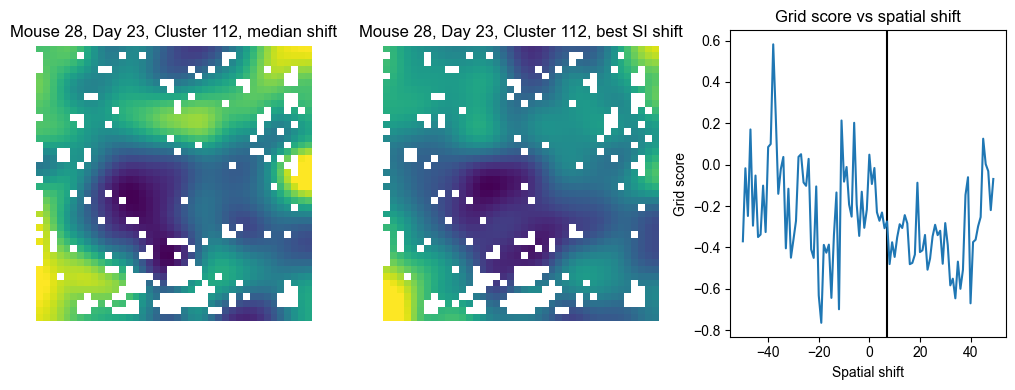

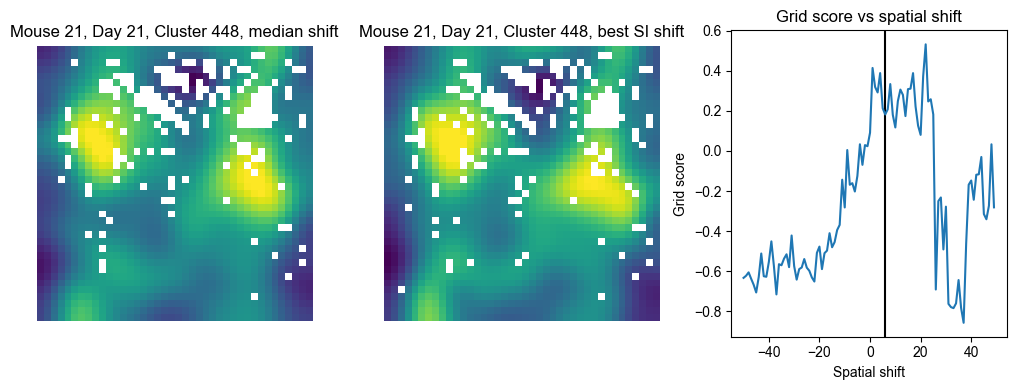

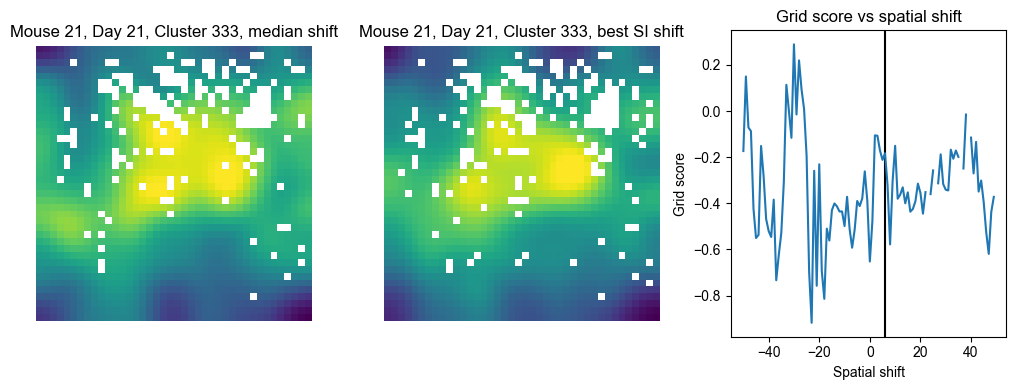

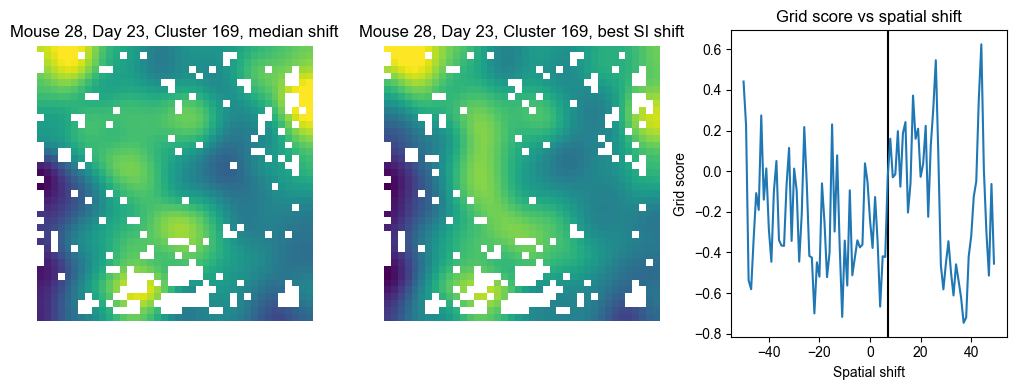

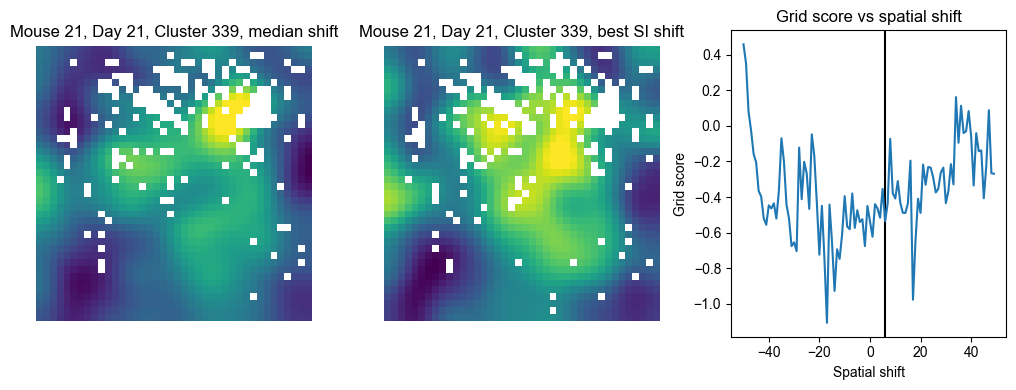

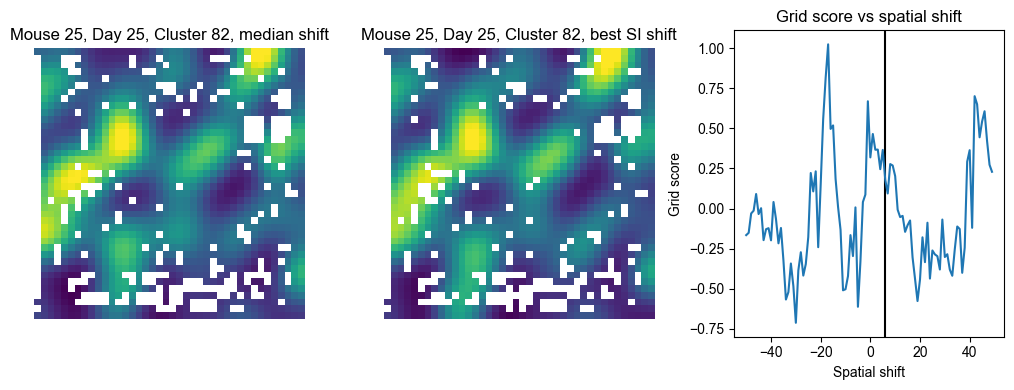

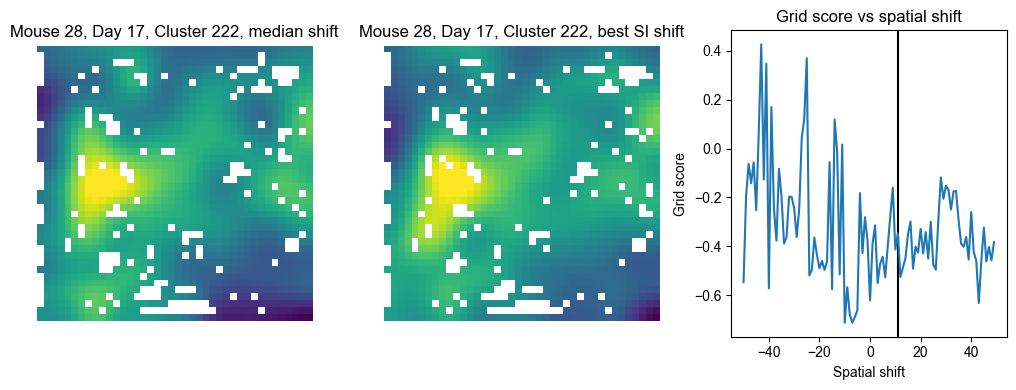

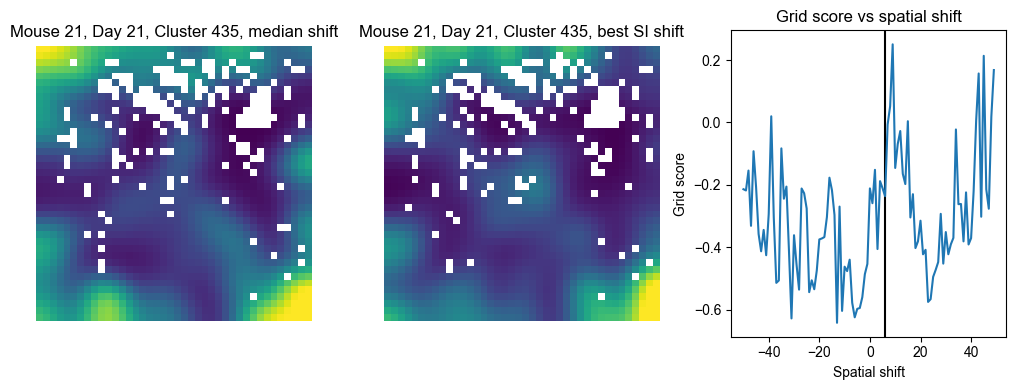

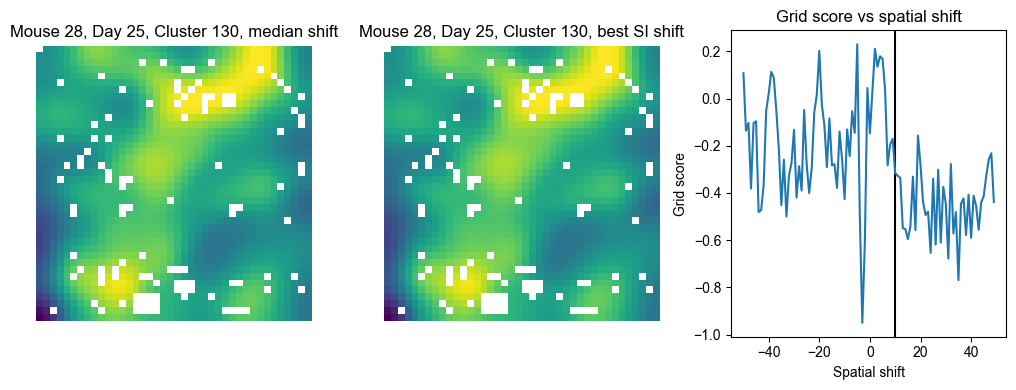

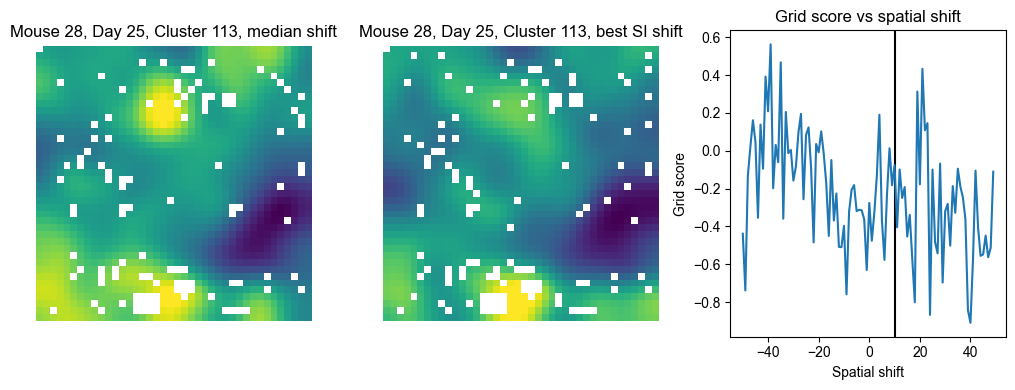

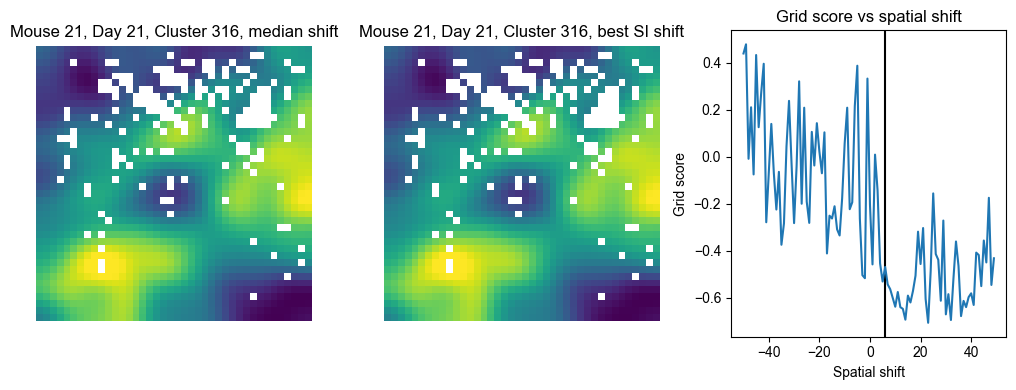

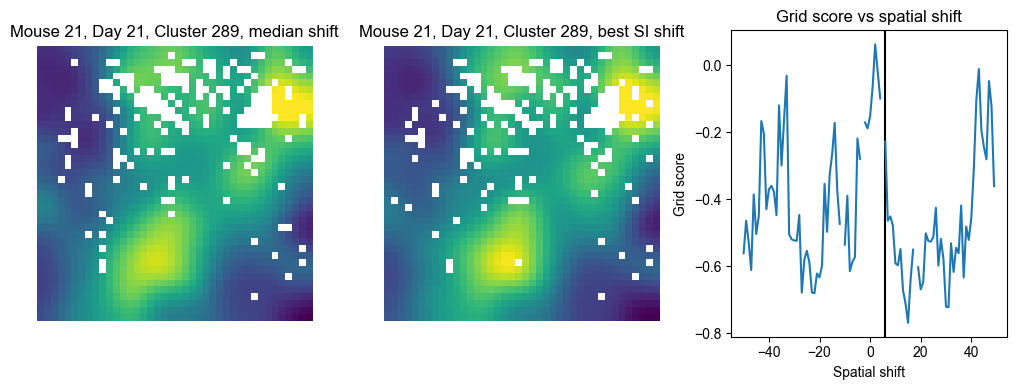

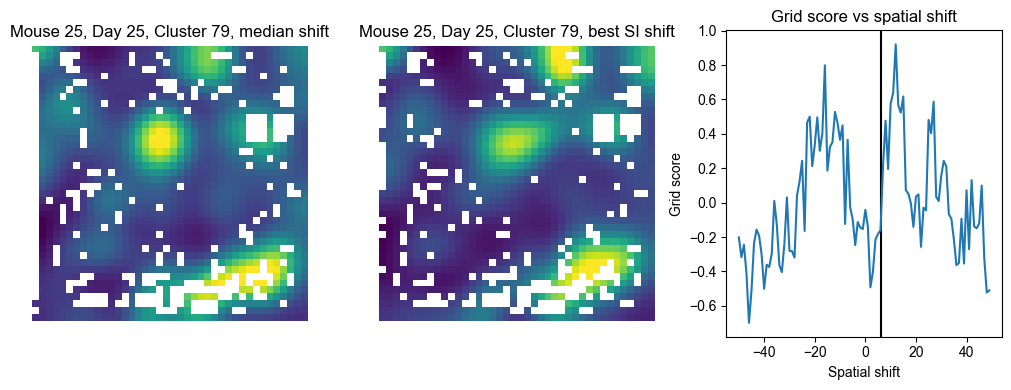

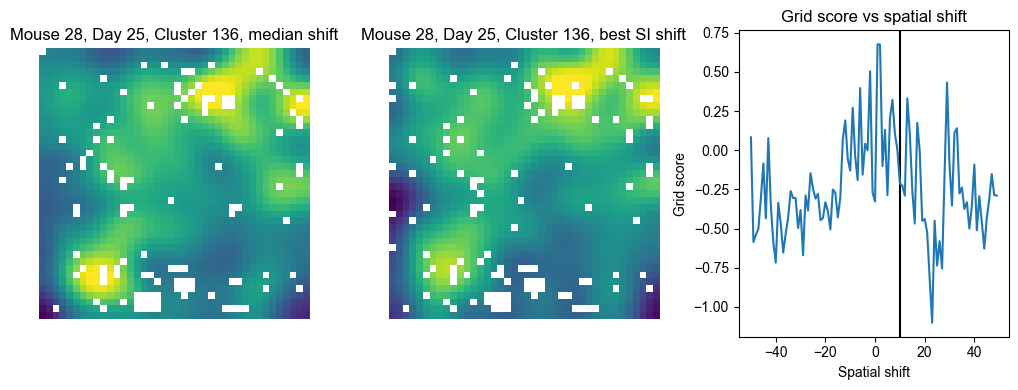

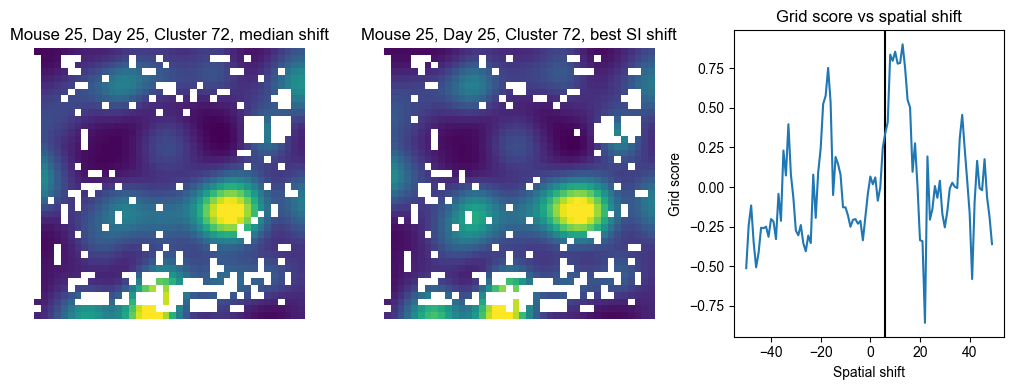

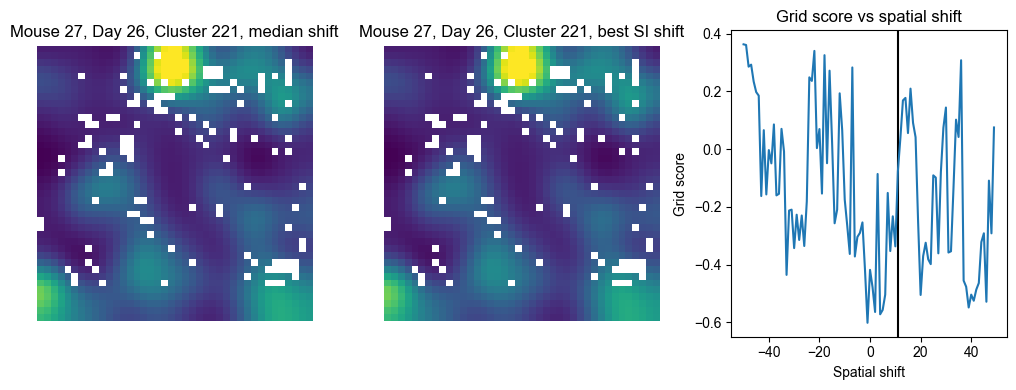

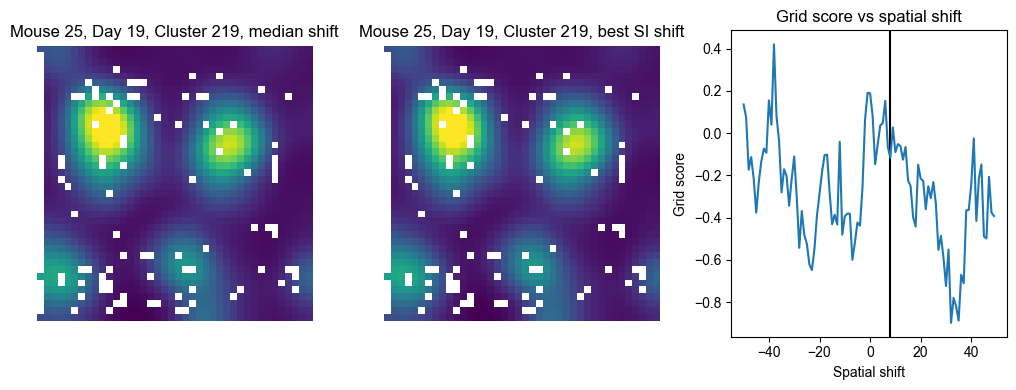

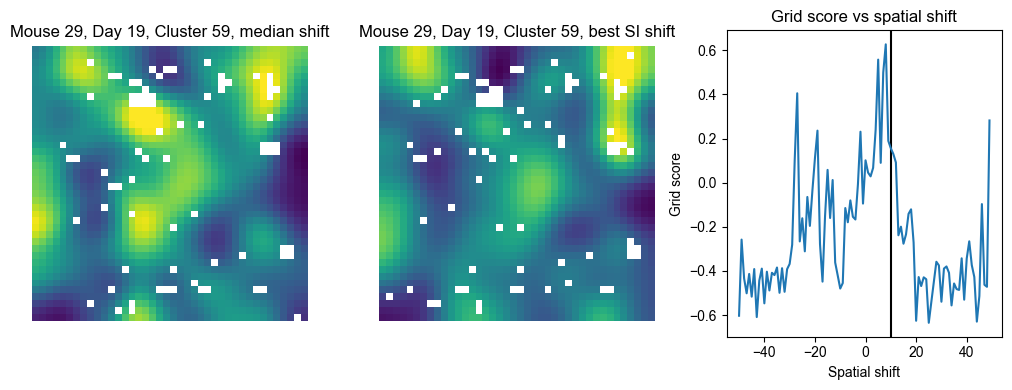

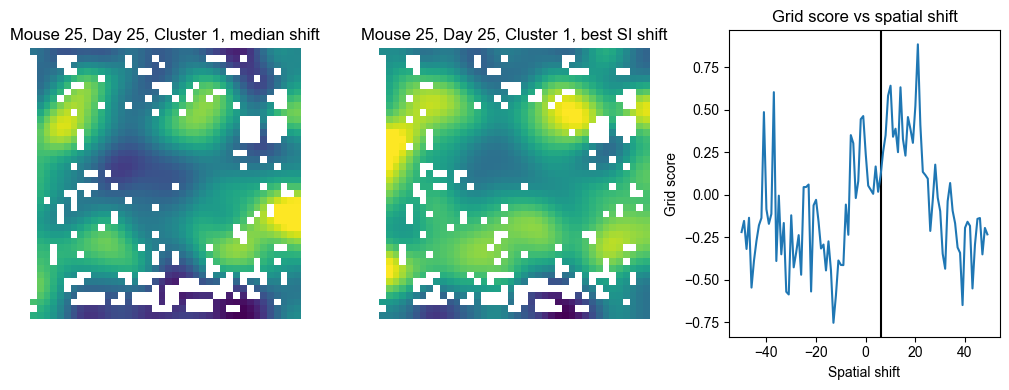

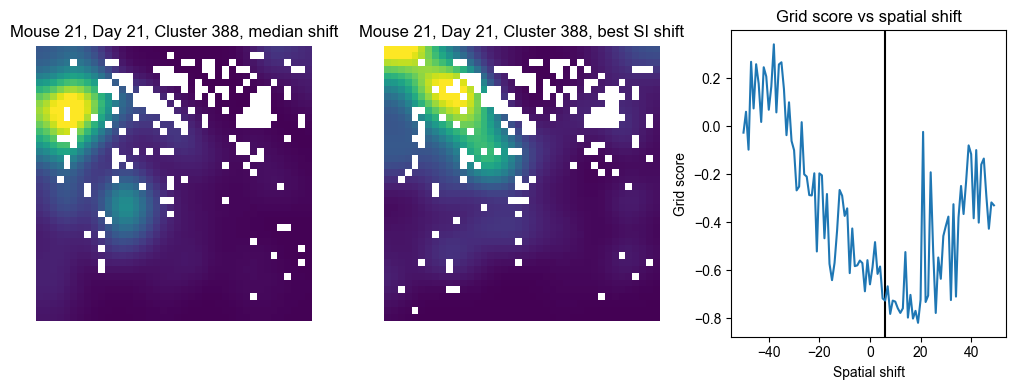

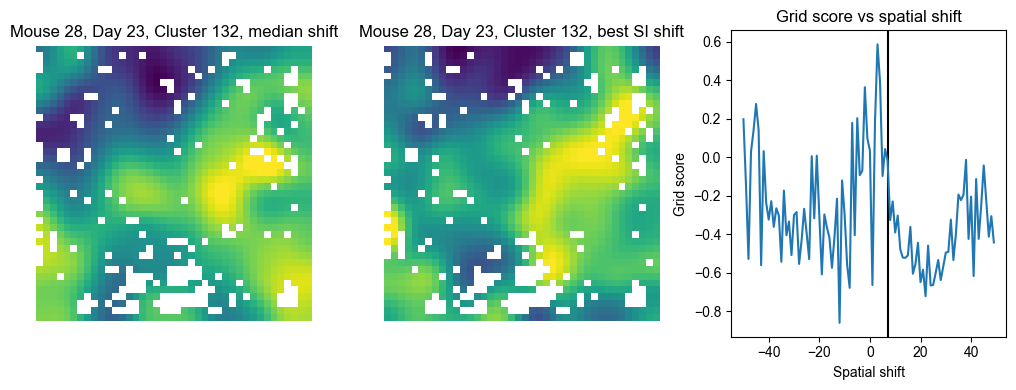

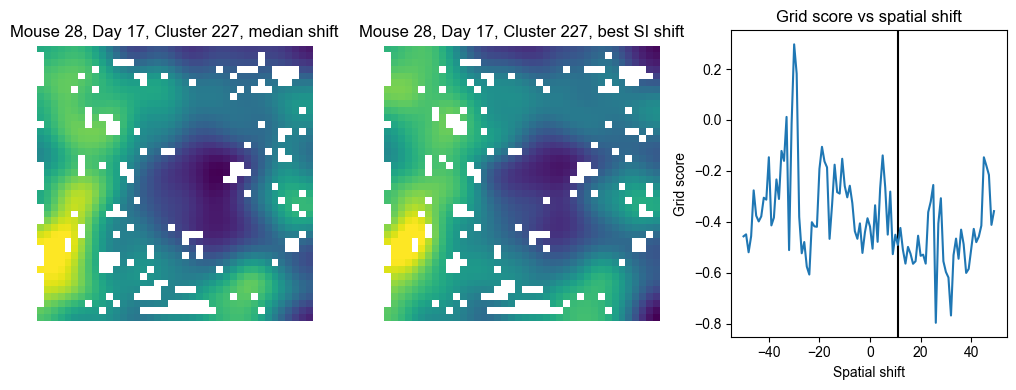

KeyboardInterrupt: 

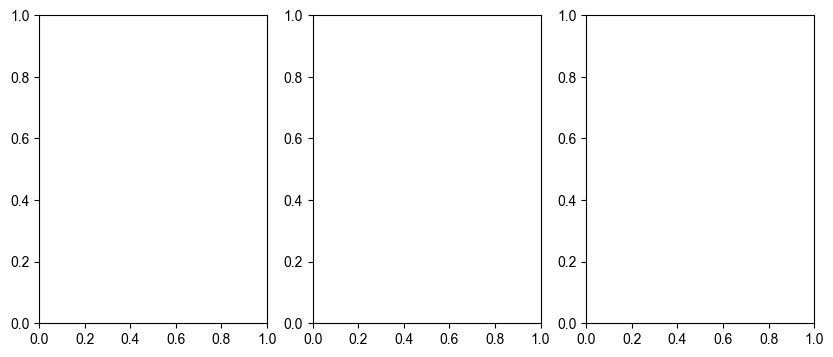

In [34]:
# For the top 50 ranked cells, plot open field rate map and grid_travel_scores vs spatial shift
from spatial_manifolds.detect_grids import plot_open_field_rate_map_optimal_ax

# Get top 50 from ranked DataFrame
ranked_top = ranked.head(50)

for idx, row in ranked_top.iterrows():
    cluster_id_cov = row['cluster_id_cov']
    day = row['day'] if 'day' in row else row.get('day', None)
    mouse = row['mouse'] if 'mouse' in row else row.get('mouse', None)
    # Find the corresponding cell in ngs_
    ngs_row = ngs_[(ngs_['cluster_id'] == cluster_id_cov) & (ngs_['day'] == day) & (ngs_['mouse'] == mouse)]
    if ngs_row.empty:
        continue
    ngs_row = ngs_row.iloc[0]
    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    # Open field rate map

    plot_open_field_rate_map_optimal_ax(axs[0], cluster_id_cov, mouse, day, ngs_row.to_frame().T, optimal_method='median')
    axs[0].set_title(f"Mouse {mouse}, Day {day}, Cluster {cluster_id_cov}, median shift")
    
    plot_open_field_rate_map_optimal_ax(axs[1], cluster_id_cov, mouse, day, ngs_row.to_frame().T, optimal_method='best_spatial_information')
    axs[1].set_title(f"Mouse {mouse}, Day {day}, Cluster {cluster_id_cov}, best SI shift")

    # Grid travel scores vs spatial shift
    grid_travel_scores = ngs_row['grid_travel_scores']
    grid_travel_scores = np.array(grid_travel_scores)
    
    spatial_shift = np.arange(-50, 50, 1)
    axs[2].axvline(ngs_row.travel, color='black')
    axs[2].plot(spatial_shift, grid_travel_scores)
    axs[2].set_xlabel('Spatial shift')
    axs[2].set_ylabel('Grid score')
    axs[2].set_title('Grid score vs spatial shift')
    plt.tight_layout()
    plt.show()

Mouse 20, Day 25: Best k = 2, silhouette score = 0.569
Mouse 21, Day 16: Best k = 2, silhouette score = 0.643
Mouse 21, Day 21: Best k = 2, silhouette score = 0.497
Mouse 21, Day 25: Best k = 2, silhouette score = 0.331
Mouse 21, Day 26: Best k = 2, silhouette score = 0.559
Mouse 25, Day 19: Best k = 6, silhouette score = 0.310
Mouse 25, Day 20: Best k = 2, silhouette score = 0.452
Mouse 25, Day 21: Best k = 2, silhouette score = 0.282
Mouse 25, Day 22: Best k = 2, silhouette score = 0.289
Mouse 25, Day 24: Best k = 2, silhouette score = 0.362
Mouse 25, Day 25: Best k = 3, silhouette score = 0.437
Mouse 26, Day 15: Best k = 2, silhouette score = 0.531
Mouse 26, Day 18: Best k = 2, silhouette score = 0.316
Mouse 27, Day 20: Best k = 3, silhouette score = 0.248
Mouse 27, Day 23: Best k = 4, silhouette score = 0.210
Mouse 27, Day 24: Best k = 2, silhouette score = 0.573
Mouse 27, Day 26: Best k = 3, silhouette score = 0.270
Mouse 28, Day 17: Best k = 2, silhouette score = 0.582
Mouse 28, 

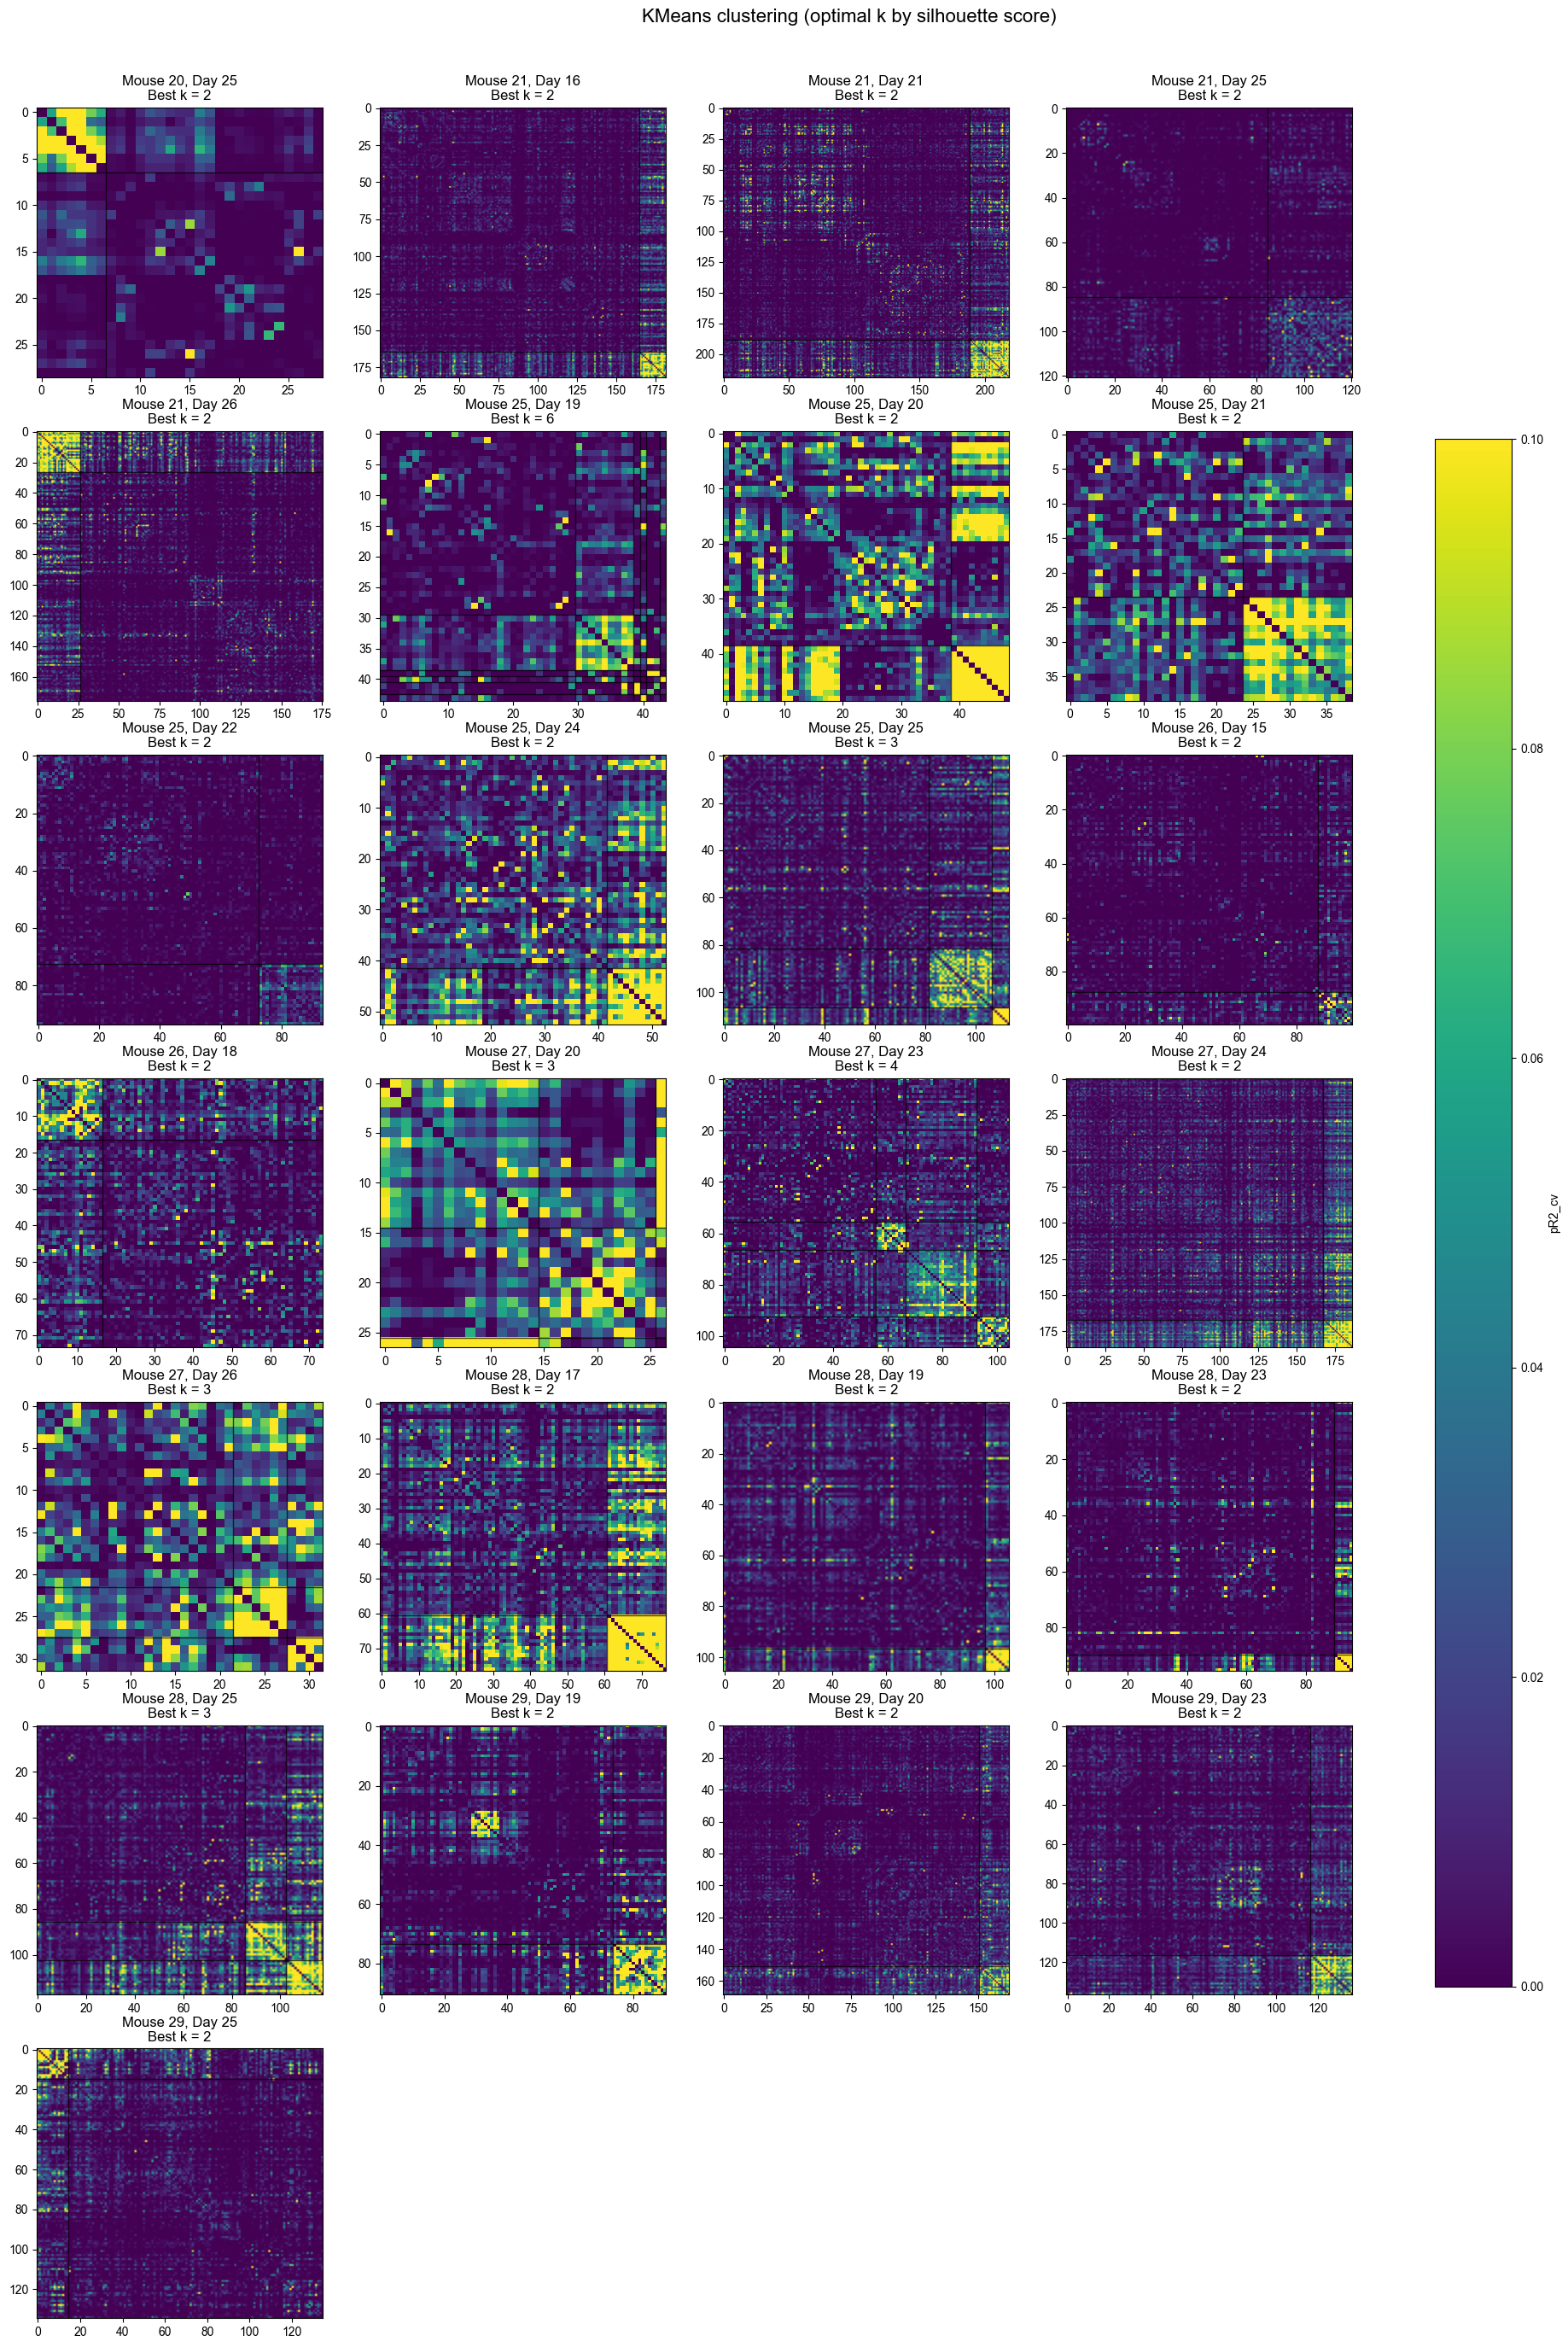

In [57]:
# KMeans clustering with silhouette score to determine optimal k, all sessions in one figure
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

max_k = 8  # Maximum number of clusters to try
sessions = list(neuron_only.groupby(['mouse', 'day']).groups.keys())
n_sessions = len(sessions)
ncols = min(4, n_sessions)
nrows = int(np.ceil(n_sessions / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))  # wider for colorbar
axes = np.array(axes).reshape(-1)

for idx, ((mouse, day), group) in enumerate(neuron_only.groupby(['mouse', 'day'])):
    neurons = group['cluster_id'].unique()
    n = len(neurons)
    neuron_idx = {cid: i for i, cid in enumerate(neurons)}
    mat = np.full((n, n), np.nan)
    for _, row in group.iterrows():
        i = neuron_idx[row['cluster_id']]
        j = neuron_idx[row['cluster_id_cov']]
        mat[i, j] = row['pR2_cv']
        mat[j, i] = row['pR2_cv']
    mat = np.nan_to_num(mat, nan=0)
    X = mat
    best_k = 2
    best_score = -1
    best_labels = None
    for k in range(2, min(max_k, n)+1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
        labels = kmeans.fit_predict(X)
        if len(np.unique(labels)) < 2 or len(np.unique(labels)) == n:
            continue
        score = silhouette_score(X, labels, metric='euclidean')
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
    print(f"Mouse {mouse}, Day {day}: Best k = {best_k}, silhouette score = {best_score:.3f}")
    order = np.argsort(best_labels)
    mat_sorted = mat[np.ix_(order, order)]
    ax = axes[idx]
    im = ax.imshow(mat_sorted, aspect='auto', cmap='viridis', vmin=0, vmax=0.1)
    ax.set_title(f'Mouse {mouse}, Day {day}\nBest k = {best_k}')
    #ax.set_xlabel('Neuron (clustered)')
    #ax.set_ylabel('Neuron (clustered)')
    prev = 0
    for cl in np.unique(best_labels[order]):
        count = np.sum(best_labels[order] == cl)
        if prev > 0:
            ax.axhline(prev-0.5, color='k', linestyle='-', linewidth=1, alpha=0.7)
            ax.axvline(prev-0.5, color='k', linestyle='-', linewidth=1, alpha=0.7)
        prev += count

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('KMeans clustering (optimal k by silhouette score)', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(wspace=0.2, hspace=0.2)
cbar = fig.colorbar(im, ax=axes[:n_sessions], shrink=0.7, label='pR2_cv')
plt.show()